In [185]:
!pip install /kaggle/input/iterative-stratification/iterative_stratification-0.1.9-py3-none-any.whl
import numpy as np
import pandas as pd
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import log_loss
from dataclasses import dataclass
from sklearn.decomposition import PCA
from sklearn.preprocessing import QuantileTransformer
import time
import xgboost as xgb
from sklearn.linear_model import LogisticRegression
from torch.optim import Optimizer
import matplotlib.pyplot as plt

Processing /kaggle/input/iterative-stratification/iterative_stratification-0.1.9-py3-none-any.whl
iterative-stratification is already installed with the same version as the provided wheel. Use --force-reinstall to force an installation of the wheel.


# Data preprocessing 

In [186]:
# train_features.shape

In [187]:
# unique_counts = train_targets.nunique()

# constant_columns = unique_counts[unique_counts == 0]
# constant_columns

In [188]:
train_features = pd.read_csv("/kaggle/input/lish-moa/train_features.csv")
train_targets  = pd.read_csv("/kaggle/input/lish-moa/train_targets_scored.csv")
# test_features  = pd.read_csv("/kaggle/input/lish-moa/test_features.csv")
train_drug = pd.read_csv('/kaggle/input/lish-moa/train_drug.csv')


train_features['cp_type'].unique()
train_features = train_features[train_features['cp_type'] == 'trt_cp'].reset_index(drop=True)
train_targets = train_targets[train_targets['sig_id'].isin(train_features['sig_id'])].reset_index(drop=True)
train_drug = train_drug[train_drug['sig_id'].isin(train_features['sig_id'])].reset_index(drop=True)

train_features = pd.get_dummies(train_features, columns=['cp_time', 'cp_dose'])

# g = [g for g in X.columns if g.startswith('g-')]
# c = [c for c in X.columns if c.startswith('c-')]

X = train_features.merge(train_drug, on='sig_id')
y = train_targets.set_index("sig_id").loc[X["sig_id"]].reset_index(drop=True)

In [189]:
GENES = [c for c in X.columns if c.startswith("g-")]
CELLS = [c for c in X.columns if c.startswith("c-")]
CATS  = [c for c in X.columns if c.startswith("cp_time_")] + [c for c in X.columns if c.startswith("cp_dose_")]
FEATS = GENES + CELLS + CATS  

test_features = pd.read_csv("/kaggle/input/lish-moa/test_features.csv")
sample_sub    = pd.read_csv("/kaggle/input/lish-moa/sample_submission.csv")

is_trt = (test_features["cp_type"] == "trt_cp").values

test_proc = pd.get_dummies(test_features, columns=["cp_time", "cp_dose"])

for col in FEATS:
    if col not in test_proc.columns:
        test_proc[col] = 0.0
test_proc = test_proc[FEATS]


The purpose of this code is to divide data into folds so that:
- no drug ('drug_id') was included in both train and validation
- at the same time, the distribution of targets (206 tags) between folds remained balanced

If we accidentally split this 'drug_id' between train and validation, the model will “spy” on the answers.

Step by step solution: 
1. Group the data by 'drug_id' and find the average values for each target.
2. Divide our preparations into folders, taking into account the balance of our targets.
3. Retrieve data by 'drug_id' and obtain a balanced dataset.

In [190]:
def make_drug_stratified_folds(X, y, n_splits=5, random_state=128):
    drug_level_targets = y.copy()
    drug_level_targets["drug_id"] = X["drug_id"].values
    drug_level_targets = drug_level_targets.groupby('drug_id').mean().reset_index()

    mskf = MultilabelStratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    drug_folds = {}

    for fold, (train_idx, val_idx) in enumerate(mskf.split(drug_level_targets,drug_level_targets.drop(columns=["drug_id"]))):
        val_drugs = drug_level_targets.loc[val_idx, "drug_id"].values
        drug_folds[fold] = val_drugs

    X_folds = X.copy()
    X_folds["fold"] = -1
    for fold, val_drugs in drug_folds.items():
        X_folds.loc[X_folds["drug_id"].isin(val_drugs), 'fold'] = fold

    print(f"Created {n_splits} folds")
    return X_folds


In [191]:
X_folds = make_drug_stratified_folds(X, y, n_splits=5, random_state=128)

Created 5 folds


In [192]:
X_folds['fold'].value_counts()

fold
1    4888
2    4469
0    4325
3    4168
4    4098
Name: count, dtype: int64

In [193]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# y_with_folds = y.copy()
# y_with_folds["fold"] = X_folds["fold"]

# # середнє значення (частка 1 для кожного таргету)
# fold_means = y_with_folds.groupby("fold").mean()

# # плавніший boxplot (з кольорами, фоном і стилем)
# plt.figure(figsize=(10, 6))
# sns.set_style("whitegrid")
# sns.boxplot(data=fold_means.T, palette="pastel")
# plt.title("🔹 Розподіл частоти таргетів у кожному фолді", fontsize=14, pad=15)
# plt.ylabel("Середнє значення таргетів (частка 1)", fontsize=12)
# plt.xlabel("Фолд", fontsize=12)
# plt.xticks(range(fold_means.shape[0]), [f"Fold {i}" for i in range(fold_means.shape[0])])
# plt.tight_layout()
# plt.show()


In [194]:
# drug_counts = X_folds.groupby('fold')['drug_id'].nunique()

# plt.figure(figsize=(8, 5))
# sns.barplot(x=drug_counts.index, y=drug_counts.values, palette='coolwarm')
# plt.title("Кількість унікальних drug_id у кожному фолді", fontsize=14, pad=10)
# plt.xlabel("Фолд", fontsize=12)
# plt.ylabel("Кількість унікальних препаратів", fontsize=12)
# for i, v in enumerate(drug_counts.values):
#     plt.text(i, v + 3, str(v), ha='center', fontsize=11)
# plt.tight_layout()
# plt.show()


# Training

In [195]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE

'cuda'

In [196]:
class MoADataset(Dataset):
    def __init__(self, X, y=None):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = None if y is None else torch.tensor(y, dtype=torch.float32)
    def __len__(self): return self.X.shape[0]
    def __getitem__(self, i):
        if self.y is None: return self.X[i]
        return self.X[i], self.y[i]

In [197]:
def competition_log_loss(y_true, y_pred):
    eps = 1e-15
    p = np.clip(y_pred, eps, 1 - eps)
    y = y_true if isinstance(y_true, np.ndarray) else y_true.values
    losses = []
    for j in range(p.shape[1]):
        if len(np.unique(y[:, j])) < 2:
            continue
        proba_2 = np.stack([1.0 - p[:, j], p[:, j]], axis=1)
        losses.append(log_loss(y[:, j], proba_2, labels=[0, 1]))
    return float(np.mean(losses)) if losses else np.nan

Compensating for target imbalances in BCEWithLogitsLoss

$pos\_weight_j = \frac {(1 - p_j)} {p_j}$

If a label is rare, the standard BCE ignores it. 'pos_weight' increases the contribution of rare positives to the loss so that the model learns them better.
 UPD: total Bulshit

In [198]:
def compute_pos_weight(y_train: np.ndarray):
    freq = y_train.mean(axis=0)
    pos_w = (1 - freq) / (freq + 1e-9)
    return torch.tensor(pos_w.astype(np.float32), device=DEVICE)

In [199]:
def make_scalers_and_scale(X_tr_df, X_va_df, gene_cols, cell_cols):
    sc_g = StandardScaler()
    sc_c = StandardScaler()
    X_tr_df[gene_cols] = sc_g.fit_transform(X_tr_df[gene_cols])
    X_tr_df[cell_cols] = sc_c.fit_transform(X_tr_df[cell_cols])
    X_va_df[gene_cols] = sc_g.transform(X_va_df[gene_cols])
    X_va_df[cell_cols] = sc_c.transform(X_va_df[cell_cols])
    return X_tr_df, X_va_df, sc_g, sc_c

# make_quantile_scalers_and_scale 
def make_quantile_scalers_and_scale(X_tr_df, X_va_df, gene_cols, cell_cols, n_quantiles=1000, output_distribution="normal", random_state=128):
    qt_g = QuantileTransformer(n_quantiles=min(n_quantiles, len(X_tr_df)), output_distribution=output_distribution, 
                               subsample=int(1e9), random_state=random_state, copy=True)
    qt_c = QuantileTransformer(n_quantiles=min(n_quantiles, len(X_tr_df)),output_distribution=output_distribution,
                               subsample=int(1e9), random_state=random_state, copy=True)

    X_tr_df[gene_cols] = qt_g.fit_transform(X_tr_df[gene_cols])
    X_tr_df[cell_cols] = qt_c.fit_transform(X_tr_df[cell_cols])
    X_va_df[gene_cols] = qt_g.transform(X_va_df[gene_cols])
    X_va_df[cell_cols] = qt_c.transform(X_va_df[cell_cols])

    X_tr_df[gene_cols] = X_tr_df[gene_cols].astype("float32")
    X_tr_df[cell_cols] = X_tr_df[cell_cols].astype("float32")
    X_va_df[gene_cols] = X_va_df[gene_cols].astype("float32")
    X_va_df[cell_cols] = X_va_df[cell_cols].astype("float32")
    return X_tr_df, X_va_df, qt_g, qt_c

In [200]:
def apply_pca_per_block(X_tr, X_va, gene_cols, cell_cols, cat_cols=None,
                        n_components_g=0.90, n_components_c=0.90, random_state=42):
    if cat_cols is None:
        cat_cols = []

    pca_g = PCA(n_components=n_components_g, random_state=random_state)
    pca_c = PCA(n_components=n_components_c, random_state=random_state)

    g_tr_p = pca_g.fit_transform(X_tr[gene_cols].values).astype("float32")
    g_va_p = pca_g.transform(    X_va[gene_cols].values).astype("float32")
    c_tr_p = pca_c.fit_transform(X_tr[cell_cols].values).astype("float32")
    c_va_p = pca_c.transform(    X_va[cell_cols].values).astype("float32")

    g_cols = [f"g_pca_{i}" for i in range(g_tr_p.shape[1])]
    c_cols = [f"c_pca_{i}" for i in range(c_tr_p.shape[1])]

    base_tr = X_tr[cat_cols].reset_index(drop=True)
    base_va = X_va[cat_cols].reset_index(drop=True)

    g_tr_df = pd.DataFrame(g_tr_p, columns=g_cols, index=base_tr.index)
    g_va_df = pd.DataFrame(g_va_p, columns=g_cols, index=base_va.index)
    c_tr_df = pd.DataFrame(c_tr_p, columns=c_cols, index=base_tr.index)
    c_va_df = pd.DataFrame(c_va_p, columns=c_cols, index=base_va.index)

    X_tr_new = pd.concat([base_tr, g_tr_df, c_tr_df], axis=1)
    X_va_new = pd.concat([base_va, g_va_df, c_va_df], axis=1)

    feat_cols_new = cat_cols + g_cols + c_cols
    return X_tr_new, X_va_new, pca_g, pca_c, feat_cols_new

In [201]:
def transform_pca_per_block(X_df, gene_cols, cell_cols, pca_g, pca_c, feat_cols_new):
    g_te_p = pca_g.transform(X_df[gene_cols].values).astype("float32")
    c_te_p = pca_c.transform(X_df[cell_cols].values).astype("float32")

    g_cols = [col for col in feat_cols_new if col.startswith("g_pca_")]
    c_cols = [col for col in feat_cols_new if col.startswith("c_pca_")]
    cat_cols = [col for col in feat_cols_new if col.startswith("cp_time_") or col.startswith("cp_dose_")]

    base = X_df[cat_cols].reset_index(drop=True)
    g_df = pd.DataFrame(g_te_p, columns=g_cols, index=base.index)
    c_df = pd.DataFrame(c_te_p, columns=c_cols, index=base.index)

    X_new = pd.concat([base, g_df, c_df], axis=1)
    return X_new[feat_cols_new]

In [202]:
def build_loaders(X_tr, y_tr, X_va, y_va, batch_size):
    X_tr = np.asarray(X_tr, dtype=np.float32)
    X_va = np.asarray(X_va, dtype=np.float32)
    y_tr = np.asarray(y_tr, dtype=np.float32)
    y_va = np.asarray(y_va, dtype=np.float32)
    ds_tr = MoADataset(X_tr, y_tr)
    ds_va = MoADataset(X_va, y_va)
    dl_tr = DataLoader(ds_tr, batch_size=batch_size, shuffle=True)
    dl_va = DataLoader(ds_va, batch_size=batch_size, shuffle=False)
    return dl_tr, dl_va

### Custom layer

In [203]:
class FeatureGate(nn.Module):
    def __init__(self, d, init=0.0):
        super().__init__()
        self.alpha = nn.Parameter(torch.full((d,), float(init)))
        # init=0 -> sigmoid(0)=0.5 

    def forward(self, x):
        # x: [batch, d]
        gate = torch.sigmoid(self.alpha)  # [d] = [0,1]
        return x * gate

In [204]:
class MoAModel(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 1024),
            nn.BatchNorm1d(1024),
            FeatureGate(1024),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            FeatureGate(512),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            FeatureGate(256),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(256, out_dim) 
        )
    def forward(self, x): 
        return self.net(x)

In [205]:
@torch.no_grad()
def validate_epoch(model, loader, criterion):
    model.eval()
    total, steps = 0.0, 0
    preds, trues = [], []
    for xb, yb in loader:
        xb = xb.to(DEVICE); yb = yb.to(DEVICE).float()
        logits = model(xb)
        loss = criterion(logits, yb)
        total += loss.item()
        steps += 1
        preds.append(torch.sigmoid(logits).cpu().numpy())
        trues.append(yb.cpu().numpy())
    y_pred = np.concatenate(preds, axis=0)
    y_true = np.concatenate(trues, axis=0)
    val_loss = total / max(steps, 1)
    val_metric = competition_log_loss(y_true, y_pred)
    return val_loss, val_metric, y_pred

In [206]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total, steps = 0.0, 0
    grad_norms = []

    for xb, yb in loader:
        xb = xb.to(DEVICE); yb = yb.to(DEVICE).float()
        optimizer.zero_grad(set_to_none=True)
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        gn = torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        grad_norms.append(float(gn))
        optimizer.step()
        total += loss.item()
        steps += 1

    avg_loss = total / max(steps, 1)
    avg_gn   = float(np.mean(grad_norms)) if grad_norms else 0.0
    return avg_loss, avg_gn


In [207]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=1e-6):
        self.patience = patience
        self.min_delta = min_delta
        self.best = float('inf')
        self.wait = 0
        self.best_preds = None 

    def step(self, val_loss, preds=None):
        improved = val_loss < (self.best - self.min_delta)
        if improved:
            self.best = val_loss
            self.wait = 0
            if preds is not None:
                self.best_preds = preds.copy()
        else:
            self.wait += 1
        return improved

    def should_stop(self):
        return self.wait >= self.patience


### Custom opt

In [208]:
class MySimpleSGD(Optimizer):
    # p <- (1 - lr*wd)*p - lr * grad

    def __init__(self, params, lr=1e-2, weight_decay=0.0):
        defaults = dict(lr=lr, weight_decay=weight_decay)
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self):
        for group in self.param_groups:
            lr = group["lr"]
            wd = group["weight_decay"]
            for p in group["params"]:
                if p.grad is None:
                    continue

                if wd != 0:
                    p.data.mul_(1 - lr * wd)
                p.data.add_(p.grad, alpha=-lr)

In [209]:
@dataclass
class TrainCfg:
    epochs:int=30
    batch_size:int=256
    lr:float=1e-3
    weight_decay:float=1e-5
    grad_clip:float=1.0
    amp:bool=True
    use_pos_weight:bool=False

In [210]:
def run_fold(fold, X_df, y_df, folds_df, feat_cols, gene_cols, cell_cols, epochs=20, batch_size=256, lr=1e-3, weight_decay=1e-5,
    use_pos_weight=False, use_quantile=True, use_pca=True, pca_n_g=0.90, pca_n_c=0.90, random_state=4):
    
    tr_idx = folds_df.index[folds_df["fold"] != fold].values
    va_idx = folds_df.index[folds_df["fold"] == fold].values

    X_tr = X_df.loc[tr_idx, feat_cols].copy()
    X_va = X_df.loc[va_idx,  feat_cols].copy()
    y_tr = y_df.loc[tr_idx].values.astype(np.float32)
    y_va = y_df.loc[va_idx ].values.astype(np.float32)

    # Quantile or Standard
    if use_quantile:
        X_tr, X_va, qt_g, qt_c = make_quantile_scalers_and_scale(X_tr, X_va, gene_cols, cell_cols, n_quantiles=1000,
            output_distribution="normal", random_state=random_state)
    else:
        X_tr, X_va, qt_g, qt_c = make_scalers_and_scale(X_tr, X_va, gene_cols, cell_cols)

    # PCA
    pca_g = pca_c = None
    feat_cols_cur = feat_cols
    if use_pca:
        cat_cols = [c for c in X_tr.columns if c.startswith("cp_time_") or c.startswith("cp_dose_")]
        X_tr, X_va, pca_g, pca_c, feat_cols_cur = apply_pca_per_block(X_tr, X_va, gene_cols, cell_cols, cat_cols,
            n_components_g=pca_n_g, n_components_c=pca_n_c, random_state=random_state
        )

    dl_tr, dl_va = build_loaders(X_tr[feat_cols_cur].values, y_tr, X_va[feat_cols_cur].values, y_va, batch_size)

    model = MoAModel(in_dim=len(feat_cols_cur), out_dim=y_df.shape[1]).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    # optimizer = MySimpleSGD(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.BCEWithLogitsLoss()

    es = EarlyStopping(patience=5, min_delta=1e-6)

    best_val_loss = float("inf")
    best_val_metric = None 
    best_val_preds = None
    gn_history = []
    for ep in range(1, epochs + 1):
        tr_loss, tr_gn = train_one_epoch(model, dl_tr, optimizer, criterion)
        va_loss, va_metric, va_preds = validate_epoch(model, dl_va, criterion)

        gn_history.append(tr_gn)

        if va_loss < best_val_loss:
            best_val_loss = va_loss
            best_val_metric = va_metric
            best_val_preds = va_preds.copy()

        es.step(va_loss)
        print(f"[fold {fold}] ep {ep}  tr {tr_loss}  va {va_loss}  mcll {va_metric} | grad_norm {tr_gn}")
        if es.should_stop(): break

    transformers = {"qt_g": qt_g, "qt_c": qt_c, "pca_g": pca_g, "pca_c": pca_c}
    return best_val_loss, best_val_metric, best_val_preds, va_idx, model, transformers, feat_cols_cur, gn_history


In [211]:
def transform_test_once(X_te_df, transformers, feat_cols_cur, gene_cols, cell_cols):
    X_te = X_te_df.copy()

    X_te[gene_cols] = transformers["qt_g"].transform(X_te[gene_cols])
    X_te[cell_cols] = transformers["qt_c"].transform(X_te[cell_cols])

    if transformers["pca_g"] is not None:
        X_te = transform_pca_per_block(X_te, gene_cols, cell_cols,transformers["pca_g"], transformers["pca_c"], feat_cols_cur)
    else:
        X_te = X_te[feat_cols_cur]
    return X_te.astype(np.float32)


In [212]:
n_folds = X_folds["fold"].nunique()
n_targets = y.shape[1]

oof = np.zeros((len(X), n_targets), dtype=np.float32)
test_preds = np.zeros((len(test_proc), n_targets), dtype=np.float32)
all_grad_norms = [] 

for f in sorted(X_folds["fold"].unique()):
    va_loss, va_mcll, va_preds, va_idx, model, tfm, feat_cols_cur, gn_hist  = run_fold(
        fold=int(f),
        X_df=X, y_df=y, folds_df=X_folds,
        feat_cols=FEATS, gene_cols=GENES, cell_cols=CELLS,
        epochs=TrainCfg.epochs, batch_size=TrainCfg.batch_size,
        lr=TrainCfg.lr, weight_decay=TrainCfg.weight_decay,
        use_pos_weight=False,          
        use_quantile=True,
        use_pca=True, pca_n_g=600, pca_n_c=60,
        random_state=128)

    oof[va_idx] = va_preds
    all_grad_norms.append(gn_hist)

    X_te_final = transform_test_once(test_proc, tfm, feat_cols_cur, GENES, CELLS)

    pos = np.where(is_trt)[0]
    X_te_t = X_te_final.iloc[pos].values
    dl = DataLoader(MoADataset(X_te_t, None), batch_size=TrainCfg.batch_size, shuffle=False)

    model.eval()
    preds_fold = np.zeros((len(test_proc), n_targets), dtype=np.float32)
    cur = 0
    with torch.no_grad():
        for xb in dl:
            xb = xb.to(DEVICE)
            pr = torch.sigmoid(model(xb)).cpu().numpy()
            n = pr.shape[0]
            preds_fold[pos[cur:cur+n]] = pr
            cur += n

    test_preds += preds_fold / n_folds


print("OOF mean column-wise logloss:", competition_log_loss(y.values, oof))

# sub = sample_sub.copy()
# sub.iloc[:, 1:] = test_preds.astype(np.float32)
# sub.to_csv("submission.csv", index=False)
# print("Saved submission.csv")


[fold 0] ep 1  tr 0.24627006917759992  va 0.0886349081993103  mcll 0.09051415109874929 | grad_norm 0.08869905305513437
[fold 0] ep 2  tr 0.04205975076858548  va 0.03617036824717241  mcll 0.03882262271719441 | grad_norm 0.02467898982644513
[fold 0] ep 3  tr 0.027192310497596645  va 0.026023539988433615  mcll 0.02904978740277339 | grad_norm 0.011079698679563791
[fold 0] ep 4  tr 0.023291761109578438  va 0.023630109341705546  mcll 0.02678985825532273 | grad_norm 0.007691030424304198
[fold 0] ep 5  tr 0.021458701702995575  va 0.02199909310130512  mcll 0.0252436012559855 | grad_norm 0.006587804443594338
[fold 0] ep 6  tr 0.020265533899267513  va 0.021241725915495085  mcll 0.024520470855521604 | grad_norm 0.006153107168611841
[fold 0] ep 7  tr 0.01934676517502985  va 0.020254210733315525  mcll 0.02356072078813155 | grad_norm 0.006001011245762525
[fold 0] ep 8  tr 0.01868227480546288  va 0.01991664935999057  mcll 0.023221840226481744 | grad_norm 0.005994073985873357
[fold 0] ep 9  tr 0.018134

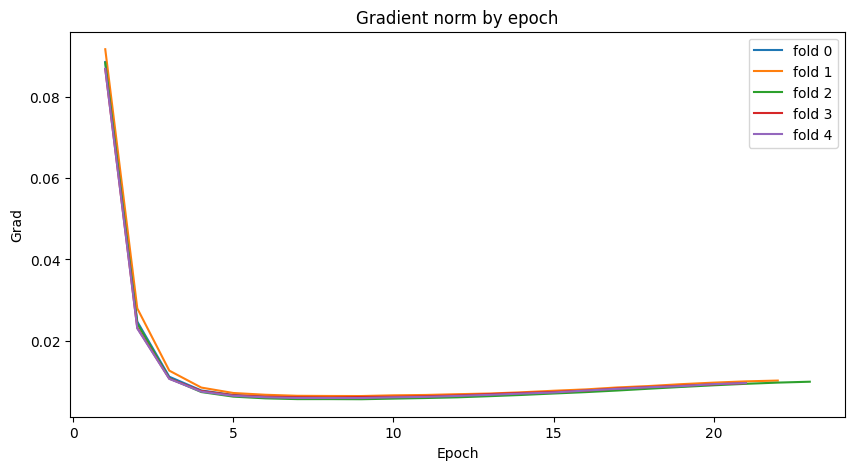

In [213]:
plt.figure(figsize=(10, 5))
for fold_id, gn_hist in enumerate(all_grad_norms):
    epochs = range(1, len(gn_hist)+1)
    plt.plot(epochs, gn_hist, label=f"fold {fold_id}")
plt.xlabel("Epoch")
plt.ylabel("Grad")
plt.title("Gradient norm by epoch")
plt.legend()


# XGBoost

In [214]:
# WHEEL_DIR="/kaggle/input/pytorch-tabnet-4-1-0-py3-none-any"   
# !pip install --no-deps --no-index --find-links "$WHEEL_DIR" "$WHEEL_DIR/pytorch_tabnet-4.1.0-py3-none-any.whl"

# from pytorch_tabnet.tab_model import TabNetRegressor

In [215]:
xgb_params = {
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "tree_method": "gpu_hist",      
    "predictor": "gpu_predictor",  
    "max_depth": 6,
    "eta": 0.05,                    
    "subsample": 0.8,
    "colsample_bytree": 0.6,
    "lambda": 1.0,
    "alpha": 0.0,
    "verbosity": 0,
}

NUM_BOOST_ROUND = 700
EARLY_STOPPING  = 40
PRINT_EVERY = 25

### Quantile

In [216]:
def transform_quantile_only(X_tr, X_va, gene_cols, cell_cols, n_quantiles=1000,output_distribution="normal", random_state=128):
    t0 = time.time()
    print(f"[QT] fit on train: genes={len(gene_cols)}, cells={len(cell_cols)} | "f"n_quantiles={min(n_quantiles, len(X_tr))}, out='{output_distribution}'")
    qt_g = QuantileTransformer(n_quantiles=min(n_quantiles, len(X_tr)), output_distribution=output_distribution,
                               subsample=int(1e9), random_state=random_state, copy=True)
    qt_c = QuantileTransformer(n_quantiles=min(n_quantiles, len(X_tr)), output_distribution=output_distribution,
        subsample=int(1e9), random_state=random_state, copy=True)

    X_tr = X_tr.copy() 
    X_va = X_va.copy()
    X_tr[gene_cols] = qt_g.fit_transform(X_tr[gene_cols])
    X_tr[cell_cols] = qt_c.fit_transform(X_tr[cell_cols])
    X_va[gene_cols] = qt_g.transform(X_va[gene_cols])
    X_va[cell_cols] = qt_c.transform(X_va[cell_cols])

    dt = time.time() - t0
    print(f"[QT] done in {dt}s | X_tr={X_tr.shape}, X_va={X_va.shape}")
    return X_tr, X_va, qt_g, qt_c

In [217]:
def transform_test_quantile_only(X_te_df, qt_g, qt_c, feat_cols, gene_cols, cell_cols):
    X_te = X_te_df.copy()
    X_te[gene_cols] = qt_g.transform(X_te[gene_cols])
    X_te[cell_cols] = qt_c.transform(X_te[cell_cols])
    out = X_te[feat_cols].astype(np.float32)
    print(f"[QT-TEST] done | X_te={out.shape}")
    return out

### Train

In [218]:
def train_xgb_one_fold(fold, X_df, y_df, folds_df, feat_cols, gene_cols, cell_cols,
    xgb_params, num_boost_round=700, early_stopping_rounds=40, seed=128):
    t_fold = time.time()

    tr_idx = folds_df.index[folds_df["fold"] != fold].values
    va_idx = folds_df.index[folds_df["fold"] == fold].values
    # print(f"\n[XGB][fold {fold}] start | train={len(tr_idx)} valid={len(va_idx)} | feats={len(feat_cols)}")

    X_tr = X_df.loc[tr_idx, feat_cols].copy()
    X_va = X_df.loc[va_idx,  feat_cols].copy()
    y_tr = y_df.loc[tr_idx].values.astype(np.float32)
    y_va = y_df.loc[va_idx ].values.astype(np.float32)

    X_tr, X_va, qt_g, qt_c = transform_quantile_only(X_tr, X_va, gene_cols, cell_cols, random_state=seed)

    # just for better performance 
    X_tr_m = np.ascontiguousarray(X_tr[feat_cols].astype(np.float32).values)
    X_va_m = np.ascontiguousarray(X_va[feat_cols].astype(np.float32).values)

    # 1 vs rest
    n_targets = y_tr.shape[1]
    va_preds = np.zeros((X_va_m.shape[0], n_targets), dtype=np.float32)
    models = []

    t_loop = time.time()
    running_best = []

    for j in range(n_targets):
        dtr = xgb.DMatrix(X_tr_m, label=y_tr[:, j])
        dva = xgb.DMatrix(X_va_m, label=y_va[:, j])

        booster = xgb.train(
            params={**xgb_params, "seed": seed + j},
            dtrain=dtr,
            num_boost_round=num_boost_round,
            evals=[(dtr, "train"), (dva, "valid")],
            early_stopping_rounds=early_stopping_rounds,
            verbose_eval=False)
        
        # use only trees up to and including the best iteration, not all 700 (overfiting)
        va_preds[:, j] = booster.predict(dva, iteration_range=(0, booster.best_iteration + 1))
        models.append(booster)

        # just print
        best_it = getattr(booster, "best_iteration", None)
        if best_it is None:
            best_it = booster.num_boosted_rounds()

        best_score = getattr(booster, "best_score", None)
        running_best.append(best_score if best_score is not None else np.nan)

        if (j + 1) % PRINT_EVERY == 0 or j + 1 == n_targets:
            rb = np.array(running_best, dtype=float)
            print(
                f"[XGB][fold {fold}] target {j+1}/{n_targets} | "
                f"best_iter={best_it} | last_best_logloss={best_score if best_score is not None else 'n/a'} | "
                f"avg_best_logloss_so_far={np.nanmean(rb)}")

    print(f"[XGB][fold {fold}] done {n_targets} targets in {(time.time()-t_loop)}")

    fold_mcll = competition_log_loss(y_va, np.clip(va_preds, 1e-7, 1-1e-7))
    print(f"[XGB][fold {fold}] fold mcll={fold_mcll} | val preds shape: {va_preds.shape} | "f"total {(time.time()-t_fold)}")

    transformers = {"qt_g": qt_g, "qt_c": qt_c}
    return va_preds, va_idx, models, transformers


In [219]:
xgb_oof = np.zeros_like(y.values, dtype=np.float32)
xgb_test_preds = np.zeros((len(test_proc), y.shape[1]), dtype=np.float32)
n_folds = X_folds["fold"].nunique()

for f in sorted(X_folds["fold"].unique()):
    va_preds, va_idx, models, tfm = train_xgb_one_fold( fold=int(f), X_df=X, y_df=y, folds_df=X_folds, feat_cols=FEATS, 
                                                       gene_cols=GENES, cell_cols=CELLS,
                                                       xgb_params=xgb_params, num_boost_round=NUM_BOOST_ROUND,
                                                       early_stopping_rounds=EARLY_STOPPING, seed=128+int(f))
    
    xgb_oof[va_idx] = va_preds

    # TEST
    # X_te_final = transform_test_quantile_only(test_proc, tfm["qt_g"], tfm["qt_c"], FEATS, GENES, CELLS)
    # pos = np.where(is_trt)[0]
    # X_te_t = np.ascontiguousarray(X_te_final.iloc[pos].values.astype(np.float32))

    # preds_fold = np.zeros((len(test_proc), y.shape[1]), dtype=np.float32)
    # dte = xgb.DMatrix(X_te_t)
    # for j, booster in enumerate(models):
    #     preds = booster.predict(dte, iteration_range=(0, booster.best_iteration+1)).astype(np.float32)
    #     preds_fold[pos, j] = preds

    # xgb_test_preds += preds_fold / n_folds

print("XGB OOF mean column-wise logloss:", competition_log_loss(y.values, xgb_oof))

[QT] fit on train: genes=772, cells=100 | n_quantiles=1000, out='normal'
[QT] done in 6.8999762535095215s | X_tr=(17623, 877), X_va=(4325, 877)
[XGB][fold 0] target 25/206 | best_iter=93 | last_best_logloss=0.01073132601117101 | avg_best_logloss_so_far=0.020774572901474633
[XGB][fold 0] target 50/206 | best_iter=84 | last_best_logloss=0.02080280411404401 | avg_best_logloss_so_far=0.01811621170303733
[XGB][fold 0] target 75/206 | best_iter=104 | last_best_logloss=0.01077881048683809 | avg_best_logloss_so_far=0.01822964860497888
[XGB][fold 0] target 100/206 | best_iter=78 | last_best_logloss=0.078816185507202 | avg_best_logloss_so_far=0.01959153029873034
[XGB][fold 0] target 125/206 | best_iter=90 | last_best_logloss=0.01958333592062461 | avg_best_logloss_so_far=0.018764991856116377
[XGB][fold 0] target 150/206 | best_iter=105 | last_best_logloss=0.02167129811408224 | avg_best_logloss_so_far=0.01807104741864583
[XGB][fold 0] target 175/206 | best_iter=261 | last_best_logloss=0.0011590868

# Ensembling

In [220]:
weights = np.linspace(0.30, 0.70, 2)
best_w = None
best_loss = 1e9
for w in weights:
    blend_oof_try = w*xgb_oof + (1-w)*oof
    loss = competition_log_loss(y.values, np.clip(blend_oof_try, 1e-7, 1-1e-7))
    if loss < best_loss:
        best_loss, best_w = loss, float(w)

print(f"[BLEND] best_w={best_w}  OOF={best_loss}")

blend_oof  = np.clip(best_w*xgb_oof  + (1-best_w)*oof, 1e-7, 1-1e-7)
blend_test = np.clip(best_w*xgb_test_preds + (1-best_w)*test_preds, 1e-7, 1-1e-7)

print("[BLEND] done:", "blend_oof", blend_oof.shape, "blend_test", blend_test.shape)


[BLEND] best_w=0.7  OOF=0.019210645354104064
[BLEND] done: blend_oof (21948, 206) blend_test (3982, 206)


In [221]:
n_targets = y.shape[1]
stack_oof  = np.zeros_like(oof, dtype=np.float32)
stack_test = np.zeros_like(test_preds, dtype=np.float32)

META = LogisticRegression(penalty="l2", solver="lbfgs", max_iter=1000, class_weight=None)

for j in range(n_targets):
    # X_meta_train: NN, XGB, BLEND
    X_meta_tr = np.stack([oof[:, j], xgb_oof[:, j], blend_oof[:, j]], axis=1)
    y_tr_j    = y.values[:, j]

    # constant columns (just copy nn)
    if len(np.unique(y_tr_j)) < 2:
        stack_oof[:, j]  = blend_oof[:, j]
        stack_test[:, j] = blend_test[:, j]
        continue

    # Meta 
    meta = META.fit(X_meta_tr, y_tr_j)

    # OOF
    stack_oof[:, j] = meta.predict_proba(X_meta_tr)[:, 1].astype(np.float32)

    # TEST
    X_meta_te = np.stack([test_preds[:, j], xgb_test_preds[:, j], blend_test[:, j]], axis=1)
    stack_test[:, j] = meta.predict_proba(X_meta_te)[:, 1].astype(np.float32)

stack_oof = np.clip(stack_oof, 1e-7, 1-1e-7)
print("[STACK] OOF mcll:", competition_log_loss(y.values, np.clip(stack_oof, 1e-7, 1-1e-7)))

# submission 
sub_stack = sample_sub.copy()
sub_stack.iloc[:, 1:] = stack_test.astype(np.float32)
sub_stack.to_csv("submission.csv", index=False)
print("Saved submission_stacking.csv")

[STACK] OOF mcll: 0.019853446347532864
Saved submission_stacking.csv
